<a href="https://colab.research.google.com/github/chavacodezen/Maestria-IA/blob/main/Practica20_268838.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   Nombre: Bryan Fernando Chavarria Martinez
*   Matricula: 268838

**ACTIVIDAD**

Ejercicios de EDA usando AirQuality

**OBJETIVO**

Realizar un Análisis Exploratorio de Datos (EDA) aplicando técnicas estadísticas y de visualización para comprender la estructura, distribución y relaciones dentro de un conjunto de datos. Utilza el archivo AirQuality que se proprociona.

**INSTRUCCIONES**

1.   La actividad debe realizarse obligatoriamente en Google Colab.
2.   El notebook debe incluir: código en Python, visualizaciones, celdas de texto con interpretación de los resultados.
3.   Cada sección del análisis debe estar claramente documentada.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv(
    "drive/MyDrive/ClassFiles/Unidad02/AirQuality.csv",
    sep=';',
    decimal=',',
    encoding='latin1'
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **1. Introducción del dataset**

Incluye una sección donde expliques:
*   Nombre del dataset
*   Fuente de donde fue obtenido
*   Número de observaciones
*   Número de variables
*   Descripción de las variables

También debes mostrar:
*   Primeras filas del dataset (head())
*   Estructura del dataset (info())

In [42]:
print("Dataset: AirQuality.csv\n")

print(f"Forma del Dataset (Filas, Columnas): {df.shape}")

print("\nNúmero de observaciones:", df.shape[0])
print("Número de variables:", df.shape[1])

print("\nDescripción de las variables")
print(df.dtypes)

print("\nPrimeras filas del dataset:")
print(df.head())

print("\nEstructura del dataset:")
print(df.info())

Dataset: AirQuality.csv

Forma del Dataset (Filas, Columnas): (9471, 17)

Número de observaciones: 9471
Número de variables: 17

Descripción de las variables
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object

Primeras filas del dataset:
         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004  18.00.00     2.6       1360.0     150.0      11.9   
1  10/03/2004  19.00.00     2.0       1292.0     112.0       9.4   
2  10/03/2004  20.00.00     2.2       1402.0      88.0       9.0   
3  10/03/2004  21.00.00     2.2       1376.0      80.0       9.2   
4  10/03/2004  22.00.00     1.6   

## **2.  Exploración inicial de datos**

Realiza lo siguiente:
*   Identificar valores faltantes
*   Analizar tipos de variables
*   Revisar posibles valores atípicos
*   Mostrar estadísticas descriptivas básicas (describe())

Explica brevemente lo que observas.

In [43]:
print("Valores Faltantes por columna:")
print(df.isnull().sum())

pct = (df.isnull().mean() * 100).round(2)
print("\nPorcentaje de valores nulos:")
print(pct)

print("\nDatos duplicados por columna:")
print(df.duplicated().sum())

print("\nTipos de variables:")
print(df.dtypes)

print("\nDetección de posibles valores atípicos (min/max):")
print(df.describe().loc[["min", "max"]])

print("\nEstadísticas descriptivas:")
print(df.describe())

print("\nObservaciones")
print("""\nAl inspeccionar el archivo original, se observa que cada fila termina con delimitadores adicionales (;;), lo que genera columnas vacías al momento de cargar los datos con pandas.
Estas columnas son interpretadas como Unnamed: 15 y Unnamed: 16, las cuales contienen únicamente valores nulos y no representan información útil.
Este comportamiento es consecuencia del formato del archivo.
""")
print("""\nSe observa que todas las variables principales del dataset presentan exactamente 114 valores faltantes, lo que sugiere un patrón consistente en la ausencia de datos.
Este comportamiento indica que los valores nulos probablemente no están distribuidos de manera aleatoria, sino que corresponden a registros completos (filas) sin información, posiblemente derivados de fallas en la recolección de datos en momentos específicos.
""")
print("""\nSe identificaron 113 registros duplicados exactos dentro del dataset. Al analizar este resultado en conjunto con los valores faltantes, es muy probable que esos 113 duplicados no sean datos reales repetidos, sino filas completamente vacías repetidas en el dataset.
""")

Valores Faltantes por columna:
Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64

Porcentaje de valores nulos:
Date               1.2
Time               1.2
CO(GT)             1.2
PT08.S1(CO)        1.2
NMHC(GT)           1.2
C6H6(GT)           1.2
PT08.S2(NMHC)      1.2
NOx(GT)            1.2
PT08.S3(NOx)       1.2
NO2(GT)            1.2
PT08.S4(NO2)       1.2
PT08.S5(O3)        1.2
T                  1.2
RH                 1.2
AH                 1.2
Unnamed: 15      100.0
Unnamed: 16      100.0
dtype: float64

Datos duplicados por columna:
113

Tipos de variables:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)    

## **3. Análisis univariado**

Analiza una variable individualmente.

Para variables numéricas, elige algunas de las siguientes herramientas:
*   Histogramas + KDE
*   Boxplot

Para variables categóricas, si existe, elige una de ellas incluye una de las siguientes herramientas (elige la que quieras):
*   Gráficas de barras
*   Gráficas de pastel

En cada gráfico debes interpretar brevemente los resultados.

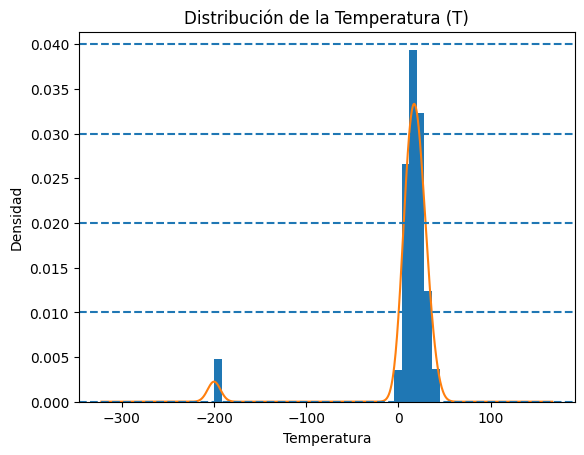



El histograma muestra que la mayor concentración de datos se encuentra en el rango aproximado entre 12°C y 20°C, donde se alcanza una densidad máxima cercana a 0.039, indicando que este es el intervalo más frecuente dentro del dataset.
Se identifica un valor mínimo de -200, el cual se encuentra muy alejado del resto de los datos.
Esto sugiere que dicho valor corresponde a un código de datos faltantes o error de medición, valores atípicos en la distribución.




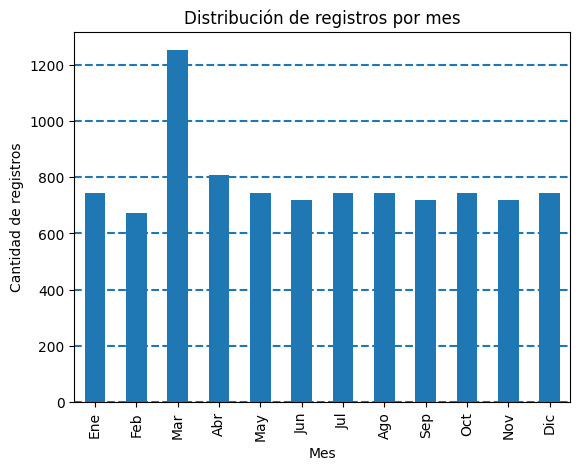



La gráfica de barras muestra la cantidad de registros por mes, donde destaca que el mes de marzo presenta una cantidad significativamente mayor de observaciones (1254) en comparación con otros meses, que oscilan entre 700 y 800 registros.



In [44]:
# Histograma + KDE
plt.figure()
df["T"].plot(kind="hist", bins=30, density=True)
df["T"].plot(kind="kde")

for y in np.arange(0, 0.05, 0.01):
    plt.axhline(y, linestyle='--')

plt.title("Distribución de la Temperatura (T)")
plt.xlabel("Temperatura")
plt.ylabel("Densidad")

plt.show()

print("""\n
El histograma muestra que la mayor concentración de datos se encuentra en el rango aproximado entre 12°C y 20°C, donde se alcanza una densidad máxima cercana a 0.039, indicando que este es el intervalo más frecuente dentro del dataset.
Se identifica un valor mínimo de -200, el cual se encuentra muy alejado del resto de los datos.
Esto sugiere que dicho valor corresponde a un código de datos faltantes o error de medición, valores atípicos en la distribución.
\n""")

# Crear mes a partir de Date
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["Month"] = df["Date"].dt.month

# Gráfica de barras
plt.figure()
conteo_mes = df["Month"].value_counts().sort_index()
conteo_mes.plot(kind="bar")

for y in np.arange(0, 1400, 200):
    plt.axhline(y, linestyle='--')

plt.xticks(
    ticks=range(len(conteo_mes)),
    labels=["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"][:len(conteo_mes)]
)

plt.title("Distribución de registros por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de registros")

plt.show()

print("""\n
La gráfica de barras muestra la cantidad de registros por mes, donde destaca que el mes de marzo presenta una cantidad significativamente mayor de observaciones (1254) en comparación con otros meses, que oscilan entre 700 y 800 registros.
""")

## **4. Análisis bivariado**

Analiza relaciones entre dos variables. Elige las variables que gustes.

**Numérica vs Numérica**

Utiliza:
*   Scatter plots

Explica qué relaciones observas.

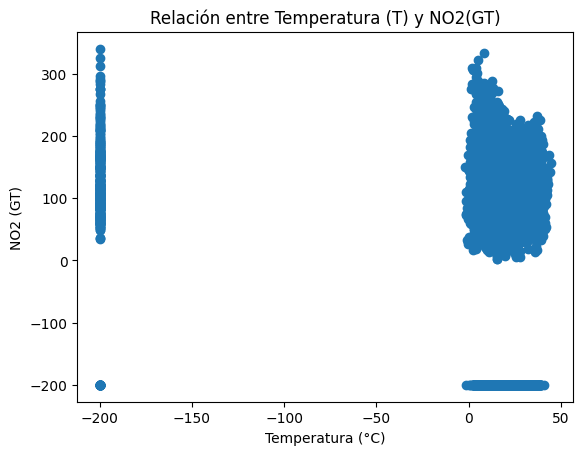


Scatter Plot con datos limpios:



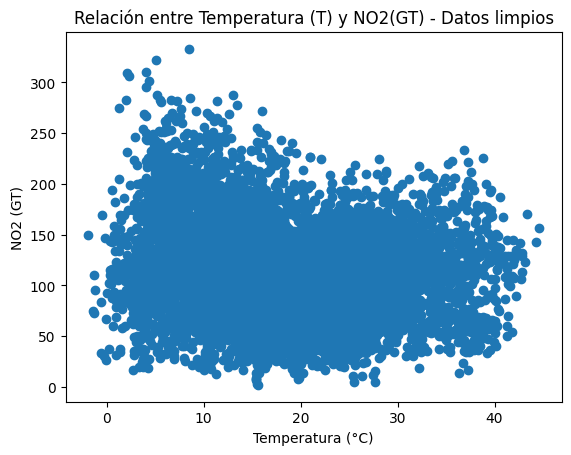



El gráfico de dispersión muestra la relación entre la temperatura (T) y la concentración de dióxido de nitrógeno (NO2).
Se observa una alta dispersión de los datos, lo que indica que no existe una relación lineal fuerte entre ambas variables.
La presencia de valores atípicos (como -200) afecta significativamente la visualización.



In [53]:
plt.figure()

plt.scatter(df["T"], df["NO2(GT)"])
plt.title("Relación entre Temperatura (T) y NO2(GT)")
plt.xlabel("Temperatura (°C)")
plt.ylabel("NO2 (GT)")

plt.show()

# Limpieza del Dataset
df_without200 = df[(df["T"] != -200) & (df["NO2(GT)"] != -200)]
print("\nScatter Plot con datos limpios:\n")

plt.figure()
plt.scatter(df_without200["T"], df_without200["NO2(GT)"])
plt.title("Relación entre Temperatura (T) y NO2(GT) - Datos limpios")
plt.xlabel("Temperatura (°C)")
plt.ylabel("NO2 (GT)")

plt.show()

print("""
\nEl gráfico de dispersión muestra la relación entre la temperatura (T) y la concentración de dióxido de nitrógeno (NO2).
Se observa una alta dispersión de los datos, lo que indica que no existe una relación lineal fuerte entre ambas variables.
La presencia de valores atípicos (como -200) afecta significativamente la visualización.
""")

## **5. Análisis multivariado**

Realiza análisis considerando múltiples variables.

Incluye: Mapa de Calor - Correlación entre variables

Shape anterior: (9471, 17)
Shape limpio: (9357, 15)




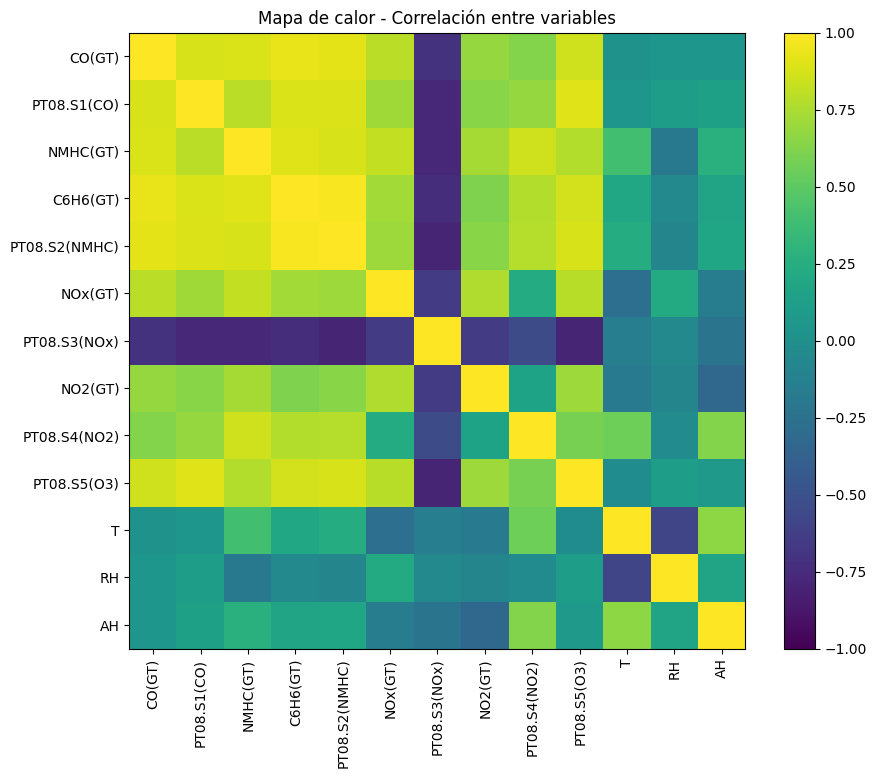



Para generar el mapa de calor, se seleccionaron únicamente las variables numéricas del dataset, ya que el cálculo de correlación requiere datos cuantitativos.
Posteriormente, se calculó la matriz de correlación y se visualizó mediante un heatmap, permitiendo identificar relaciones positivas y negativas entre las variables.



In [65]:
df_clean = df.copy()

# Quitar columnas basura
df_clean = df_clean.drop(columns=["Unnamed: 15", "Unnamed: 16"], errors='ignore')

# Reemplazar -200
df_clean = df_clean.replace(-200, np.nan)

# Eliminar filas completamente vacías
df_clean = df_clean.dropna(how='all')

# Eliminar duplicados
df_clean = df_clean.drop_duplicates()

print("Shape anterior:", df.shape)
print("Shape limpio:", df_clean.shape)
print("\n")

# Seleccionar solo columnas numéricas
df_numeric = df_clean.select_dtypes(include=[np.number])

# Calcular correlación
corr_matrix = df_numeric.corr()

# Heatmap
plt.figure(figsize=(10,8))

plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Mapa de calor - Correlación entre variables")

plt.show()

print("""
\nPara generar el mapa de calor, se seleccionaron únicamente las variables numéricas del dataset, ya que el cálculo de correlación requiere datos cuantitativos.
Posteriormente, se calculó la matriz de correlación y se visualizó mediante un heatmap, permitiendo identificar relaciones positivas y negativas entre las variables.
""")

## **6. Identificación de patrones**

Con base en el análisis realizado, responde:
*   **¿Qué patrones importantes encontraste?**

    Se identificó que los datos presentan patrones temporales y estructurales, donde la cantidad de registros por mes no es uniforme. En particular, el mes de marzo muestra una cantidad significativamente mayor de observaciones.

    Asimismo, se detectó la presencia de valores inválidos (como -200), utilizados como indicadores de datos faltantes, lo que afecta directamente la distribución de varias variables.

*   **¿Existen relaciones entre variables?**

    Sí, el análisis de correlación muestra que existen relaciones positivas entre varios contaminantes, como: CO(GT) / NO2(GT) / C6H6(GT)

    Esto indica que estos contaminantes tienden a aumentar o disminuir conjuntamente, lo cual es consistente con fuentes comunes de emisión como el tráfico vehicular o actividades industriales.

    Por otro lado, variables ambientales como temperatura (T) y humedad (RH, AH) presentan relaciones más débiles, sugiriendo que su influencia sobre los contaminantes es indirecta.

*   **¿Se observan clusters naturales?**

    En los gráficos de dispersión se observa cierta agrupación de datos en rangos específicos, particularmente en valores moderados de temperatura y concentraciones de contaminantes.

    Sin embargo, no se identifican clusters claramente definidos o separados, lo que indica que los datos tienen una distribución continua más que segmentada.

*   **¿Existen outliers?**

    Sí, se identificaron múltiples valores atípicos, especialmente:
    - Valores extremos como -200, en todas las columnas.
    - Posibles valores anómalos en algunas variables que se alejan significativamente del rango general.
    
    Estos outliers afectan tanto la visualización como el análisis estadístico, por lo que es importante tratarlos adecuadamente durante el proceso de limpieza.

*   **¿Qué variables parecen ser más relevantes?**

    Las variables más relevantes son aquellas relacionadas con los contaminantes del aire, como:
    - CO(GT)
    - NO2(GT)
    - C6H6(GT)
    - NOx(GT)
    
    Además, los sensores PT08 también resultan relevantes, ya que muestran correlación con los contaminantes, lo que sugiere que capturan adecuadamente su comportamiento.

    Estas variables son clave para entender la dinámica de la calidad del aire y su variación a lo largo del tiempo.